In [12]:
import numpy as np
import matplotlib.pyplot as plt
from utils import *
import copy
import math
%matplotlib inline

In [2]:
#loading the dataset
x_train, y_train = load_data()

In [5]:
#print x_train #POPULATION OF THE CITY
print("type :", type(x_train))
print('first 5 elements :\n', x_train[:5])

type : <class 'numpy.ndarray'>
first 5 elements :
 [6.1101 5.5277 8.5186 7.0032 5.8598]


In [6]:
#print y_train #AVG MONTHLY PROFITS
print("type :", type(y_train))
print('first 5 elements :\n', y_train[:5])

type : <class 'numpy.ndarray'>
first 5 elements :
 [17.592   9.1302 13.662  11.854   6.8233]


In [9]:
#shapes
print(x_train.shape) #the shape 
print(y_train.shape) #the shape 
print(len(x_train)) # # of training examples

(97,)
(97,)
97


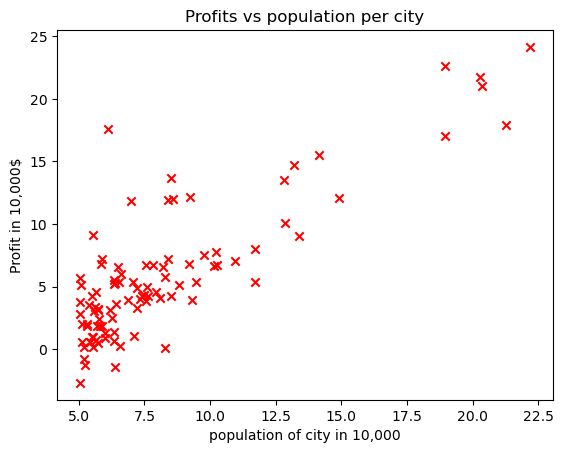

In [14]:
#VISUALIZE THE DATA
plt.scatter( x_train,y_train, marker='x',c='r')
plt.title("Profits vs population per city")
plt.ylabel("Profit in 10,000$")
plt.xlabel("population of city in 10,000")
plt.show()

In [48]:
#COMPUTE COST- Loop through every data point. For each one, 
#              calculate how wrong your prediction is. Square it so negatives don't cancel positives.
#              Average all errors. That's your score.

def compute_cost(x, y, w, b):

    m = x.shape[0]    # Count the total number of data points
    total_cost = 0
    
    # Loop through every single data point
    for i in range(m):
        # Calculate the model's prediction line
        f_wb = w * x[i] + b
        
        # Calculate how wrong it is and square it so negatives don't cancel positives
        cost = (f_wb - y[i]) ** 2
        
        # Add to the running total error score
        total_cost += cost
        
    # Average all errors to get the final score
    total_cost = total_cost / (2 * m)
    
    return total_cost

In [51]:
# 1. Define manual, non-zero starting guesses for our parameters
initial_w = 2
initial_b = 1

# 2. Run our custom cost function using the real training dataset
cost = compute_cost(x_train, y_train, initial_w, initial_b)

# 3. Verify that the function returns a single numerical value (float) and not a list
print(type(cost))

# 4. Print the final average error score
print(f"cost at initial w:{cost:.3f}")


<class 'numpy.float64'>
cost at initial w:75.203


In [57]:
#compute_gradient - Loop through every data point. Calculate the error. 
#                  The gradient for w gets pushed by error times the input. 
#                  The gradient for b gets pushed by error alone. Average both. 
#                  These tell you which direction to move.


def compute_gradient(x, y, w, b):
    m = x.shape[0]

    dj_dw = 0
    dj_db = 0
    
    # Loop through every single data point in the dataset
    for i in range(m):
        # Calculate the model's current prediction line
        f_wb = w * x[i] + b
        
        # Calculate the raw distance error between prediction and true value
        error = f_wb - y[i]
        
        # Accumulate the raw error to determine the step direction for bias (b)
        dj_db += error
        
        # Multiply error by the feature value to scale the step direction for weight (w)
        dj_dw += error * x[i]
        
    # Calculate the average gradients across the entire dataset
    dj_db = dj_db / m
    dj_dw = dj_dw / m

    return dj_dw, dj_db

In [62]:
# Initialize our parameters to zero to establish a baseline starting point
initial_w = 0
initial_b = 0

# Run our custom gradient function to calculate the initial slopes/derivatives
tmp_dj_dw, tmp_dj_db = compute_gradient(x_train, y_train, initial_w, initial_b)

# Print the baseline gradients (negative values mean we need to increase w and b)
print('GRADIENT AT INITIAL W, B (ZEROS):', tmp_dj_dw, tmp_dj_db)

# Pass our custom function into the automated test suite to verify the calculus logic
compute_gradient_test(compute_gradient)



GRADIENT AT INITIAL W, B (ZEROS): -65.32884974555672 -5.83913505154639
Using X with shape (4, 1)
All tests passed!


In [63]:
# Define specific, non-zero parameters to evaluate the gradient behavior
test_w = 0.2
test_b = 0.2

# Run our updated gradient function
tmp_dj_dw, tmp_dj_db = compute_gradient(x_train, y_train, test_w, test_b)

# Print the resulting directional adjustment
print('GRADIENT AT TEST W, B :', tmp_dj_dw, tmp_dj_db)


GRADIENT AT TEST W, B : -47.41610118114435 -4.007175051546391


In [64]:
def gradient_descent(x, y, w, b, compute_cost, compute_gradient, alpha, iterations):
    
    for i in range(iterations):
        # Calculate the current slopes and derivatives of the cost mountain
        dj_dw, dj_db = compute_gradient(x, y, w, b)
        
        # Update the weight parameter by taking a step downhill proportional to alpha
        w = w - alpha * dj_dw
        
        # Update the bias parameter by taking a step downhill proportional to alpha
        b = b - alpha * dj_db
        
    # Return the final optimized parameters after all training iterations finish
    return w, b


In [65]:
# Initialize starting parameters to zero before training begins
initial_w = 0
initial_b = 0

# Set the optimization settings for the step size and total training loops
iterations = 1500
alpha = 0.01

# Execute the gradient descent loop to learn the best-fitting line parameters
w, b = gradient_descent(x_train, y_train, initial_w, initial_b, compute_cost, compute_gradient, alpha, iterations)

# Print the final optimized weight and bias values found by the algorithm
print("W, B FOUND BY GRADIENT DESCENT:", w, b)


W, B FOUND BY GRADIENT DESCENT: 1.166362350335582 -3.63029143940436


In [66]:
# Count the total number of training data rows in the dataset
m = x_train.shape[0]

# Initialize a blank array of zeros
predicted = np.zeros(m)

# Loop through every single city to compute individual predictions
for i in range(m):
    # Calculate the model prediction using the optimized line formula
    predicted[i] = w * x_train[i] + b


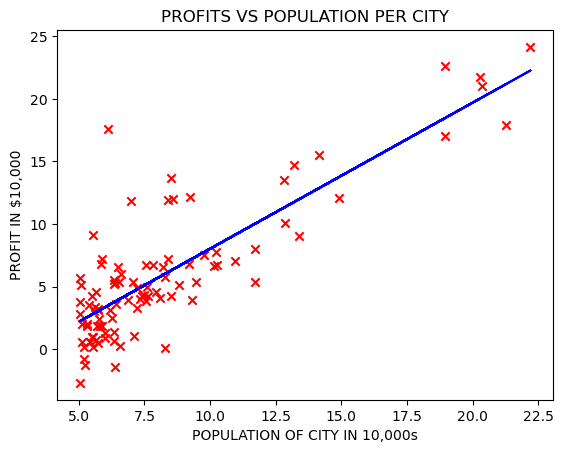

In [67]:
#PLOT LINEAR FIT
plt.plot(x_train, predicted, c = 'b')
plt.scatter(x_train, y_train, marker = 'x', c = 'r')
plt.title("PROFITS VS POPULATION PER CITY")
plt.ylabel("PROFIT IN $10,000")
plt.xlabel("POPULATION OF CITY IN 10,000s")
plt.show()

In [68]:
# predict what the profit would be in areas of 35,000 and 70,000 people.

predict1 = 3.5 * w + b 
print("For population = 35,000, we predict a profit of $%.2f" % (predict1*10000))

predict2 = 7.0 * w + b 
print("For population = 70,000, we predict a profit of $%.2f" % (predict2*10000))

For population = 35,000, we predict a profit of $4519.77
For population = 70,000, we predict a profit of $45342.45
